- DIA on ViT model 

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device)

Device: cuda


- Core ViT model for gray images (channel = 1)

In [2]:
# ============================================================
# HFFH_ViT: Hybrid Freehand Imaging ViT (MobileViT-style)
# Approximation faithful to the printed architecture you gave
# Input:  (B, 1, H, W)
# Output: (B, 1, H, W)
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

# ---------- Core transformer components ----------

class PreNorm(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.fn = fn

    def forward(self, x):
        # x: (B, N, dim)
        return self.fn(self.norm(x))


class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class Attention(nn.Module):
    def __init__(self, dim, heads=4, dim_head=8, dropout=0.0):
        """
        dim: token embedding dim (8 or 16 in HFFH_ViT)
        heads: 4, so 3 * heads * dim_head = 96 = to_qkv out_features
        dim_head: 8
        """
        super().__init__()
        inner_dim = dim_head * heads * 3  # for q, k, v
        self.heads = heads
        self.dim_head = dim_head

        self.to_qkv = nn.Linear(dim, inner_dim, bias=False)
        self.attend = nn.Softmax(dim=-1)
        self.to_out = nn.Sequential(
            nn.Linear(dim_head * heads, dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        """
        x: (B, N, dim)
        """
        b, n, _ = x.shape
        qkv = self.to_qkv(x)  # (B, N, 3 * heads * dim_head)
        qkv = qkv.view(b, n, 3, self.heads, self.dim_head)
        q, k, v = qkv.unbind(dim=2)  # each: (B, N, heads, dim_head)

        # (B, heads, N, dim_head)
        q = q.permute(0, 2, 1, 3)
        k = k.permute(0, 2, 1, 3)
        v = v.permute(0, 2, 1, 3)

        scale = self.dim_head ** -0.5
        dots = torch.matmul(q, k.transpose(-1, -2)) * scale  # (B, heads, N, N)
        attn = self.attend(dots)
        out = torch.matmul(attn, v)                           # (B, heads, N, dim_head)

        # (B, N, heads * dim_head)
        out = out.permute(0, 2, 1, 3).contiguous().view(b, n, self.heads * self.dim_head)
        out = self.to_out(out)  # (B, N, dim)
        return out


class Transformer(nn.Module):
    def __init__(self, dim, depth, mlp_dim, heads=4, dim_head=8, dropout=0.0):
        """
        dim: token dimension (8 or 16)
        depth: number of transformer layers
        mlp_dim: hidden dim in FFN (paper uses ~2x or 4x)
        """
        super().__init__()
        self.layers = nn.ModuleList([])
        for _ in range(depth):
            self.layers.append(nn.ModuleList([
                PreNorm(dim, Attention(dim, heads=heads, dim_head=dim_head, dropout=dropout)),
                PreNorm(dim, FeedForward(dim, mlp_dim, dropout=dropout)),
            ]))

    def forward(self, x):
        for attn, ff in self.layers:
            x = x + attn(x)
            x = x + ff(x)
        return x


# ---------- MobileViT-style blocks ----------

class MV2Block(nn.Module):
    """
    MobileNetV2-style depthwise separable block.
    Matches the printed pattern:
      Conv2d(C,C,3x3,groups=C) -> BN -> SiLU -> Conv2d(C,C or C->C') -> BN
    With residual if in==out and stride==1.
    """
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=stride,
                      padding=1, groups=in_channels, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.SiLU(inplace=False),
            nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(out_channels),
        )
        self.use_res_connect = (stride == 1 and in_channels == out_channels)

    def forward(self, x):
        out = self.conv(x)
        if self.use_res_connect:
            out = out + x
        return out

class MobileViTBlock(nn.Module):
    """
    MobileViT-style block:
      conv1: 3x3 (C->C)
      conv2: 1x1 (C->transformer_dim)
      transformer over patches in token dim = transformer_dim
      conv3: 1x1 (transformer_dim->C)
      conv4: 3x3 on concat(local, global) (2C->C)

    patch_size controls how big each transformer patch is (e.g., (2,2) or (4,4)).
    """
    def __init__(self, in_channels, transformer_dim, depth,
                 patch_size=(2, 2), mlp_dim=None, heads=4, dim_head=8, dropout=0.0):
        super().__init__()
        ph, pw = patch_size
        self.patch_h = ph
        self.patch_w = pw
        self.transformer_dim = transformer_dim

        # Local conv
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=1,
                      padding=1, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.SiLU(inplace=False),
        )

        # Channel projection: C -> transformer_dim (8 or 16)
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels, transformer_dim, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(transformer_dim),
            nn.SiLU(inplace=False),
        )

        if mlp_dim is None:
            mlp_dim = transformer_dim * 2  # you can change to *4 if you want to mimic 4x layers

        self.transformer = Transformer(
            dim=transformer_dim,
            depth=depth,
            mlp_dim=mlp_dim,
            heads=heads,
            dim_head=dim_head,
            dropout=dropout,
        )

        # Back to conv space: transformer_dim -> in_channels
        self.conv3 = nn.Sequential(
            nn.Conv2d(transformer_dim, in_channels, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.SiLU(inplace=False),
        )

        # Fuse local+global: (2C -> C)
        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels * 2, in_channels, kernel_size=3, stride=1,
                      padding=1, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.SiLU(inplace=False),
        )

    def forward(self, x):
        # x: (B, C, H, W)
        local_x = self.conv1(x)
        y = self.conv2(local_x)   # (B, transformer_dim, H, W)
        B, C, H, W = y.shape
        assert C == self.transformer_dim

        ph, pw = self.patch_h, self.patch_w

        # Pad so H,W divisible by patch size
        pad_h = (ph - H % ph) % ph
        pad_w = (pw - W % pw) % pw
        if pad_h != 0 or pad_w != 0:
            y = F.pad(y, (0, pad_w, 0, pad_h), mode="reflect")
            B, C, H, W = y.shape

        self._orig_hw = (H, W)

        # Unfold into non-overlapping patches
        # y_unfold: (B, C*ph*pw, L)
        y_unfold = F.unfold(y, kernel_size=(ph, pw), stride=(ph, pw))
        # reshape to (B, C, ph*pw, L) then average over patch pixels -> (B, C, L)
        y_unfold = y_unfold.view(B, C, ph * pw, -1).mean(dim=2)
        # tokens: (B, L, C)
        tokens = y_unfold.permute(0, 2, 1).contiguous()

        # Transformer over tokens
        tokens = self.transformer(tokens)  # (B, L, C)

        # Map tokens back to patches, broadcast to ph*pw pixels, fold back
        t = tokens.permute(0, 2, 1)                 # (B, C, L)
        t = t.unsqueeze(2).repeat(1, 1, ph * pw, 1) # (B, C, ph*pw, L)
        t = t.view(B, C * ph * pw, -1)              # (B, C*ph*pw, L)
        y = F.fold(t, output_size=(H, W), kernel_size=(ph, pw), stride=(ph, pw))

        # Crop to original (if we padded)
        orig_H, orig_W = self._orig_hw
        y = y[:, :, :orig_H, :orig_W]

        # Project back and fuse with local conv features
        y = self.conv3(y)
        out = torch.cat((x, y), dim=1)
        out = self.conv4(out)
        return out

# ---------- HFFH_ViT full network ----------

class HFFH_ViT(nn.Module):
    """
    Hybrid Freehand Imaging ViT
    - Input:  (B, 1, H, W)
    - Output: (B, 1, H, W)
    Matches the high-level structure you pasted:
      conv1: 1->16
      stem:  4x MV2Block(16->16)
      trunk:
        Stage1: MV2(16->16) + MobileViTBlock(16,8,depth=2)
        Stage2: MV2(16->16) + MobileViTBlock(16,8,depth=4)
        Stage3: MV2(16->32) + MobileViTBlock(32,16,depth=3)
      head:  1x1 conv 32->1
    """
    def __init__(self, img_channels=1, patch_size=(2, 2), dropout=0.0):
        super().__init__()

        # Initial conv: 1 -> 16
        self.conv1 = nn.Sequential(
            nn.Conv2d(img_channels, 16, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.SiLU(inplace=False),
        )

        # Stem: 4× MV2Block(16->16)
        self.stem = nn.ModuleList([
            MV2Block(16, 16, stride=1),
            MV2Block(16, 16, stride=1),
            MV2Block(16, 16, stride=1),
            MV2Block(16, 16, stride=1),
        ])

        # Trunk: 3 stages
        self.trunk = nn.ModuleList()

        # Stage 1: channels 16, transformer_dim=8, depth=2 (as in printout)
        stage1 = nn.ModuleList([
            MV2Block(16, 16, stride=1),
            MobileViTBlock(
                in_channels=16,
                transformer_dim=8,
                depth=2,
                patch_size=patch_size,
                mlp_dim=16,      # 2x expansion for dim=8
                heads=4,
                dim_head=8,
                dropout=dropout,
            )
        ])
        self.trunk.append(stage1)

        # Stage 2: channels 16, transformer_dim=8, depth=4
        stage2 = nn.ModuleList([
            MV2Block(16, 16, stride=1),
            MobileViTBlock(
                in_channels=16,
                transformer_dim=8,
                depth=4,
                patch_size=patch_size,
                mlp_dim=32,      # 4x expansion for dim=8
                heads=4,
                dim_head=8,
                dropout=dropout,
            )
        ])
        self.trunk.append(stage2)

        # Stage 3: MV2 16->32, transformer_dim=16, depth=3
        stage3 = nn.ModuleList([
            MV2Block(16, 32, stride=1),
            MobileViTBlock(
                in_channels=32,
                transformer_dim=16,
                depth=3,
                patch_size=patch_size,
                mlp_dim=64,      # 4x expansion for dim=16
                heads=4,
                dim_head=8,
                dropout=dropout,
            )
        ])
        self.trunk.append(stage3)

        # ------------------ Lhamo: grayscale but SiLU negative values
        '''
        # Head: 32 -> 1
        self.condense_channels = nn.Sequential(
            nn.Sequential(
                nn.Conv2d(32, 1, kernel_size=1, stride=1, bias=False),
                nn.BatchNorm2d(1),
                nn.SiLU(inplace=False),
            )
        )
        '''
        # ------------------ Lhamo: ReLU For positive output pixel
        self.condense_channels = nn.Sequential(
            nn.Conv2d(32, 1, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(1),
            nn.ReLU(inplace=False),
            )

    def forward(self, x):
        # x: (B,1,H,W)
        x = self.conv1(x)  # (B,16,H,W)

        for block in self.stem:
            x = block(x)    # (B,16,H,W)

        # Trunk stages
        for stage in self.trunk:
            mv2, mvblock = stage
            x = mv2(x)
            x = mvblock(x)

        # Now 32 channels -> 1
        out = self.condense_channels(x)
        return out


- Matched Filter Algorithm (differentiable)

In [3]:
#======================================= MFA definitions
@dataclass
class MFAParams:
    F0: float          # start freq (Hz), e.g. 77e9
    c0: float          # lightspeed, e.g. 3e8
    dx: float          # mm
    dy: float          # mm
    z0_mm: float       # target range (mm)
    bbox: tuple        # (xmin, xmax, ymin, ymax) in mm
    FS: float          # sampling rate (Hz)
    K0: float          # chirp slope (Hz/s)
    tI: float          # instrument delay (s)
    nFFTtime: int      # range FFT size, e.g. 1024
    nFFTspace: int     # spatial FFT size, e.g. 1024


def build_matched_filter(params: MFAParams, device, dtype):
    """
    PyTorch version of refMF(params) in MATLAB.
    Returns: matchedFilter (nFFTspace x nFFTspace), complex tensor.
    """
    nF = params.nFFTspace
    dx_m = params.dx * 1e-3
    dy_m = params.dy * 1e-3
    z0_m = params.z0_mm * 1e-3

    # Index grid like MATLAB: (-(nF-1)/2 : (nF-1)/2) * dx
    idx = torch.arange(nF, device=device, dtype=dtype) - (nF / 2 - 0.5)
    x = dx_m * idx                          # (nF,)
    y = dy_m * idx.view(-1, 1)              # (nF,1) -> broadcast

    k = 2.0 * torch.pi * params.F0 / params.c0   # wavenumber
    R = torch.sqrt(x**2 + y**2 + z0_m**2)        # (nF, nF)

    phase = -1j * 2.0 * k * R                    # -j 2 k R
    matched_filter = torch.exp(phase)            # complex
    return matched_filter


def mfa_image_from_slice(sarData: torch.Tensor, params: MFAParams):
    """
    Differentiable PyTorch version of dlMFA.
    sarData: (M, N) complex tensor (after range FFT + serpentine)
    Returns:
        img_mag_norm: (B, A) real tensor, RMS-normalized magnitude
        img_complex : (B, A) complex tensor
    """
    assert torch.is_complex(sarData), "sarData must be complex (torch.complex64/128)"
    device = sarData.device
    dtype  = sarData.real.dtype

    # Build matched filter on same device/dtype
    mf = build_matched_filter(params, device=device, dtype=dtype)  # (nF, nF)

    yPointM, xPointM = sarData.shape
    yPointF, xPointF = mf.shape   # both nFFTspace

    # --- zero-pad sarData up to matched filter size (like MATLAB) ---
    pad_y_pre = max((yPointF - yPointM) // 2, 0)
    pad_y_post = max(yPointF - yPointM - pad_y_pre, 0)
    pad_x_pre = max((xPointF - xPointM) // 2, 0)
    pad_x_post = max(xPointF - xPointM - pad_x_pre, 0)

    if pad_y_pre > 0 or pad_y_post > 0:
        pad_y_top = torch.zeros(pad_y_pre, xPointM, dtype=sarData.dtype, device=device)
        pad_y_bot = torch.zeros(pad_y_post, xPointM, dtype=sarData.dtype, device=device)
        sarData = torch.cat([pad_y_top, sarData, pad_y_bot], dim=0)

    if pad_x_pre > 0 or pad_x_post > 0:
        y_curr = sarData.shape[0]
        pad_x_left  = torch.zeros(y_curr, pad_x_pre, dtype=sarData.dtype, device=device)
        pad_x_right = torch.zeros(y_curr, pad_x_post, dtype=sarData.dtype, device=device)
        sarData = torch.cat([pad_x_left, sarData, pad_x_right], dim=1)

    # 2D FFT of data and matched filter
    sar_fft = torch.fft.fft2(sarData)
    mf_fft  = torch.fft.fft2(mf)

    # Convolution in freq domain, then ifft2
    img_shifted = torch.fft.ifft2(sar_fft * mf_fft)

    # fftshift (2D)
    def fftshift2d(x):
        h, w = x.shape[-2:]
        return torch.roll(torch.roll(x, shifts=h//2, dims=-2),
                          shifts=w//2, dims=-1)

    img = fftshift2d(img_shifted)

    # Crop using bbox like MATLAB
    J, I = img.shape
    bbox = params.bbox
    dx = params.dx
    dy = params.dy

    xij0 = round(bbox[0] / dx - 0.5 + I / 2.0)
    xij1 = round(bbox[1] / dx - 0.5 + I / 2.0)
    ykl0 = round(bbox[2] / dy - 0.5 + J / 2.0)
    ykl1 = round(bbox[3] / dy - 0.5 + J / 2.0)

    x0 = max(int(xij0), 0)
    x1 = min(int(xij1), I-1)
    y0 = max(int(ykl0), 0)
    y1 = min(int(ykl1), J-1)

    img_cropped = img[y0:y1+1, x0:x1+1]         # (B, A) complex

    # fliplr
    img_complex = torch.flip(img_cropped, dims=[1])

    img_mag = torch.abs(img_complex)
  
    return img_mag, img_complex

- Victim Imaging/Forward imaging: (1) MFA and (2) MFA+VIT

    imaging chain (CH1): rawSAR -> MFA -> resize -> ViT -> || [DIA] 
- Generate Target Image

In [ ]:
import torch
import torch.nn.functional as F

# ---------- ------------------------- Victim forward imaging model 
def victim_forward(raw_cube_adv: torch.Tensor, params: MFAParams, model: torch.nn.Module, mfa_or_vit: str):
    """
    raw_cube_adv: (Nsamp, M, N) complex tensor
    returns:
        if mfa_or_vit == 'mfa': (1,1,H,W) normalized MFA
        if mfa_or_vit == 'vit': (1,1,256,256) Mobile-ViT output
    """
    # Range FFT along fast time (dim=0)
    raw_fft = torch.fft.fft(raw_cube_adv, n=params.nFFTtime, dim=0)  # (nFFTtime,M,N)

    # Compute k0_range_bin
    z0_m = params.z0_mm * 1e-3
    k0_range_bin = round(
        params.K0 / params.FS * (2.0 * z0_m / params.c0 + params.tI) * params.nFFTtime
    )
    k0_range_bin = int(k0_range_bin)

    # Extract slice
    sar_slice = raw_fft[k0_range_bin, :, :]   # (M,N) complex

    # Serpentine correction
    sar_slice = sar_slice.clone()
    sar_slice[1::2, :] = torch.flip(sar_slice[1::2, :], dims=[1])

    # MFA imaging -> magnitude
    mfa_mag, _ = mfa_image_from_slice(sar_slice, params)  # (H,W)
    #----------------------------------------- mfa or ViT
    if mfa_or_vit == 'mfa':
        x = mfa_mag.unsqueeze(0).unsqueeze(0) # (1,1,H,W)
        sr_out = x  # (1,1,H,W)

    elif mfa_or_vit == 'vit':
        #x =  (mfa_mag - mfa_mag.min()) / (mfa_mag.max() - mfa_mag.min() + 1e-12)
        #x = x.unsqueeze(0).unsqueeze(0)  # (1,1,H,W)

        mx = mfa_mag.amax().detach() + 1e-12
        x  = (mfa_mag / mx).unsqueeze(0).unsqueeze(0)  # (1,1,H,W)

        # Resize to 256×256 for Mobile-ViT
        x256 = F.interpolate(x, size=(256, 256), mode="bilinear", align_corners=False)  # (1,1,256,256)
        sr_out = model(x256)  # (1,1,256,256)

    else:
        raise ValueError("mfa_or_vit must be either 'mfa' or 'vit'")
    return sr_out


'\n# ---------- ------------------------- target image generator \ndef generate_target_img(\n    data_dir: str,\n    mfa_or_vit: str,\n    device: torch.device,\n    model: torch.nn.Module | None = None,\n    filename: str = "desired_attacked_complex.mat",\n    mat_key: str = "sar_camouflaged",\n):\n    target_path = os.path.join(data_dir, filename)\n    des_np = sio.loadmat(target_path)[mat_key]  # (H,W) complex\n\n    des = torch.from_numpy(des_np).to(torch.complex64).to(device)\n\n    x = torch.abs(des).unsqueeze(0).unsqueeze(0)  # (1,1,H,W)\n\n    if mfa_or_vit == "mfa":\n        target_img = x  # (1,1,H,W)\n\n    elif mfa_or_vit == "vit":\n        if model is None:\n            raise ValueError("mfa_or_vit=\'vit\' requires model != None")\n        \n        #------------- correct desired target, no more through the model(x) \n        target_img = F.interpolate(x, size=(256, 256), mode="bilinear", align_corners=False)\n        #x = F.interpolate(x, size=(256, 256), mode="bilinear",

- Generate clean image and target image 

C:\Users\Lhamo\AppData\Local\Temp\ipykernel_9704\1026150730.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join(data_dir, "hff

raw_cube shape: torch.Size([256, 200, 200])
D_cube shape: torch.Size([256, 200, 200])


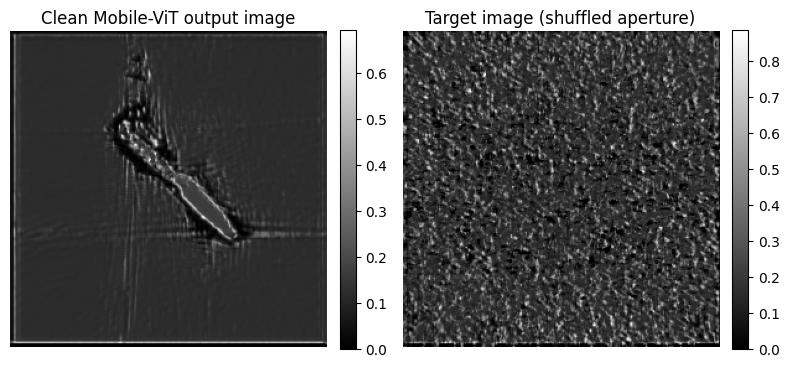

Image Type           | Min Value    | Max Value    | Shape
-----------------------------------------------------------------
Clean Mobile-ViT     | 0.0000e+00 | 6.9162e-01 | (256, 256)
Target (Shuffled)    | 0.0000e+00 | 8.8428e-01 | (256, 256)


In [24]:
import os
import torch
import scipy.io as sio

mfa_or_vit = 'vit'  # 'mfa', 'rgb', or 'vit'  # switch between the testing MFA mode and full VIT chain mode
data_dir = 'data' # data directory  

# Loads trained Mobile-ViT (1-channel) 
model = HFFH_ViT(img_channels=1, patch_size=(4, 4), dropout=0.0).to(device)
model.load_state_dict(torch.load(os.path.join(data_dir, "hffh_vit_ch1_best_epoch_015.pth"), map_location=device))
model.eval()

# Load raw adc SAR data
raw_cube = torch.as_tensor(
    sio.loadmat(os.path.join(data_dir, "rawSAR.mat"))["adcDataCube"],
    device=device
).to(torch.complex64)
Nsamp, M, N = raw_cube.shape
print("raw_cube shape:", raw_cube.shape)

params = MFAParams(
    F0        = 77e9,
    c0        = 3e8,
    dx        = 1.0,
    dy        = 1.0,
    z0_mm     = 185.0,
    bbox      = (-200.0, 200.0, -200.0, 200.0),
    FS        = 5_000_000.0,
    K0        = 70.295e12,
    tI        = 4.5225e-10,
    nFFTtime  = 1024,
    nFFTspace = 1024,
)

# Load attack waveform D from MATLAB and reshape to match raw_cube
D = torch.as_tensor(
    sio.loadmat(os.path.join(data_dir, "D.mat"))["D"],
    device=device
).to(torch.complex64)
D_cube = D.view(Nsamp, M, N)        # (Nsamp, M, N)
print("D_cube shape:", D_cube.shape)   # (Nsamp, M, N)


# ------------ Generate clean image
with torch.no_grad():
    clean_img = victim_forward(raw_cube, params, model, mfa_or_vit)
 
#global_scale = clean_img.abs().amax() + 1e-12
#clean_img = clean_img / global_scale

# ------------ Generate target image
Np = M * N
seed = 42
g = torch.Generator(device=raw_cube.device).manual_seed(seed)

raw_flat = raw_cube.reshape(Nsamp, Np)
# shuffle across aperture for each fast-time sample
raw_shuf = raw_flat.clone()
for t in range(Nsamp):
    perm = torch.randperm(Np, generator=g, device=raw_cube.device)
    raw_shuf[t] = raw_shuf[t, perm]

raw_shuf = raw_shuf.reshape(Nsamp, M, N)

with torch.no_grad():
    target_img = victim_forward(raw_shuf, params, model, mfa_or_vit)
#target_img = target_img / global_scale

import matplotlib.pyplot as plt

# squeeze to (H,W) for plotting
clean_plot  = clean_img[0, 0].detach().cpu().numpy()
target_plot = target_img[0, 0].detach().cpu().numpy()

plt.figure(figsize=(8,4))

ax1 = plt.subplot(1,2,1)
im1 = ax1.imshow(clean_plot, cmap="gray")
ax1.set_title("Clean Mobile-ViT output image"); ax1.axis("off")
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

ax2 = plt.subplot(1,2,2)
im2 = ax2.imshow(target_plot, cmap="gray")
ax2.set_title("Target image (shuffled aperture)"); ax2.axis("off")
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()
# Print Statistics Table
print(f"{'Image Type':<20} | {'Min Value':<12} | {'Max Value':<12} | {'Shape'}")
print("-" * 65)
print(f"{'Clean Mobile-ViT':<20} | {clean_plot.min():.4e} | {clean_plot.max():.4e} | {clean_plot.shape}")
print(f"{'Target (Shuffled)':<20} | {target_plot.min():.4e} | {target_plot.max():.4e} | {target_plot.shape}")

- DIA Optimization

In [25]:

# ============================================================
# DIA optimization loop with HARD per-element magnitude projection |A(m,n)| <= Amax
# (No parameterization; A_re/A_im are the actual optimization variables.)
# ============================================================

Amax           = 2.0
lambda_L2      = 1e-5
num_iters      = 1000
lr_high        = 1e0 #-------------------> 
lr_low         = 1e-2
lr_switch_iter = 10_000_000  # (effectively never)

# Decision variables (A_re, A_im) stored as trainable tensors
A_re = torch.nn.Parameter(1e-3 * torch.randn(M, N, device=device))
A_im = torch.nn.Parameter(1e-3 * torch.randn(M, N, device=device))
optimizer = torch.optim.Adam([A_re, A_im], lr=lr_high)

print(f"\n[Attack] Starting DIA optimization over A, M={M}, N={N}, Np={M*N}, lr={lr_high:.3e}\n")

for it in range(1, num_iters + 1):

    # ---- optional LR schedule ----
    if it == lr_switch_iter + 1:
        for g in optimizer.param_groups:
            g["lr"] = lr_low
        print(f"[LR SCHEDULE] Switched Adam LR from {lr_high:.3e} to {lr_low:.3e}\n")

    optimizer.zero_grad()

    # ---- build current A (unprojected) ----
    A_raw = torch.complex(A_re, A_im)                       # (M,N)

    # ---- use projected A for forward/loss (shrink-only) ----
    #mag   = torch.abs(A_raw)
    #scale = torch.clamp(Amax / (mag + 1e-12), max=1.0)
    #A     = A_raw * scale                                   # (M,N) and |A|<=Amax
    A     = A_raw 

    # ---- structured perturbation Δ(t,m,n) = D(t,m,n) * A(m,n) ----
    delta   = D_cube * A.unsqueeze(0)                       # (Nsamp,M,N)
    raw_adv = raw_cube + delta                              # (Nsamp,M,N)

    # ---- victim pipeline ----
    adv_img = victim_forward(raw_adv, params, model, mfa_or_vit)
    #adv_img = adv_img/global_scale

    # ---- losses ----
    loss_img = F.mse_loss(adv_img, target_img)
    loss_reg = lambda_L2 * torch.mean(torch.abs(A)**2)       # lambda * mean(|A|^2)
    loss     = loss_img + loss_reg

    # ---- backprop + update ----
    loss.backward()
    optimizer.step()

    # =====================================================
    # HARD PROJECTION ON PARAMETERS (CRITICAL):
    # enforce |A|<=Amax on the actual optimized variables
    # =====================================================
    with torch.no_grad():
        A_post    = torch.complex(A_re, A_im)
        mag_post  = torch.abs(A_post)
        scale_post = torch.clamp(Amax / (mag_post + 1e-12), max=1.0)
        A_proj    = A_post * scale_post
        A_re.copy_(A_proj.real)
        A_im.copy_(A_proj.imag)

    # ---- logging ----
    if it % 50 == 0 or it == 1 or it == num_iters:
        with torch.no_grad():
            A_log  = torch.complex(A_re, A_im)              # already projected
            meanA  = torch.mean(torch.abs(A_log)).item()
            maxA   = torch.max(torch.abs(A_log)).item()

            mse_AT = F.mse_loss(adv_img, target_img).item()
            mse_CA = F.mse_loss(adv_img, clean_img).item()

            PaPr   = (torch.linalg.norm(delta) /
                      (torch.linalg.norm(raw_cube) + 1e-12)).pow(2).item()

            Gnow   = torch.maximum(torch.max(torch.abs(A_re.grad)),
                                   torch.max(torch.abs(A_im.grad))).item()
            lr_now = optimizer.param_groups[0]["lr"]

        print(
            f"Iter {it:04d}/{num_iters:04d}| "
            f"Loss={loss.item():.4e}, G={Gnow:.6e} | "
            f"MSE(A,T)={mse_AT:.4e}, MSE(C,A)={mse_CA:.4e} | "
            f"E|A|={meanA:.4e}, max|A|={maxA:.4e}, Pa/Pr={PaPr:.4e}"
        )

print("Attack optimization finished.")



[Attack] Starting DIA optimization over A, M=200, N=200, Np=40000, lr=1.000e+00

Iter 0001/1000| Loss=1.9396e-02, G=5.462460e-05 | MSE(A,T)=1.9396e-02, MSE(C,A)=3.2195e-07 | E|A|=1.3919e+00, max|A|=1.4170e+00, Pa/Pr=2.0226e-06
Iter 0050/1000| Loss=5.6511e-03, G=1.767938e-05 | MSE(A,T)=5.6216e-03, MSE(C,A)=1.6613e-02 | E|A|=1.6552e+00, max|A|=2.0000e+00, Pa/Pr=2.8627e+00
Iter 0100/1000| Loss=2.5760e-03, G=8.520563e-06 | MSE(A,T)=2.5444e-03, MSE(C,A)=1.7285e-02 | E|A|=1.7263e+00, max|A|=2.0000e+00, Pa/Pr=3.0268e+00
Iter 0150/1000| Loss=1.6946e-03, G=5.005817e-06 | MSE(A,T)=1.6616e-03, MSE(C,A)=1.7734e-02 | E|A|=1.7712e+00, max|A|=2.0000e+00, Pa/Pr=3.1771e+00
Iter 0200/1000| Loss=1.5903e-03, G=7.139889e-06 | MSE(A,T)=1.5559e-03, MSE(C,A)=1.7724e-02 | E|A|=1.8155e+00, max|A|=2.0000e+00, Pa/Pr=3.3192e+00
Iter 0250/1000| Loss=1.5993e-03, G=7.721110e-06 | MSE(A,T)=1.5640e-03, MSE(C,A)=1.7783e-02 | E|A|=1.8466e+00, max|A|=2.0000e+00, Pa/Pr=3.4189e+00
Iter 0300/1000| Loss=1.6288e-03, G=8.95603

- Evaluations

In [26]:
with torch.no_grad():
    # Attacked pass (using raw_adv from the attack loop)
    adv_img   = victim_forward(raw_adv,  params, model, mfa_or_vit)

#adv_img = adv_img/global_scale
adv_img = adv_img[0].permute(1, 2, 0).cpu().numpy()
target_img = target_img[0].permute(1, 2, 0).cpu().numpy()
clean_img = clean_img[0].permute(1, 2, 0).cpu().numpy()

print(f"adv_img    min/max: {adv_img.min():.6e} / {adv_img.max():.6e}")
print(f"clean_img  min/max: {clean_img.min():.6e} / {clean_img.max():.6e}")
print(f"target_img min/max: {target_img.min():.6e} / {target_img.max():.6e}")

adv_img    min/max: 0.000000e+00 / 9.080241e-01
clean_img  min/max: 0.000000e+00 / 6.916248e-01
target_img min/max: 0.000000e+00 / 8.842753e-01



--- Mobile-ViT SR-level attack metrics ---
MSE(A,T)   : 1.6805e-03  (matlab equivalent: 3.3078e-02)
MSE(C,A)   : 1.7926e-02
NCC   : 0.9835
SSIM  : 0.9039
PSNR  : 26.68 dB


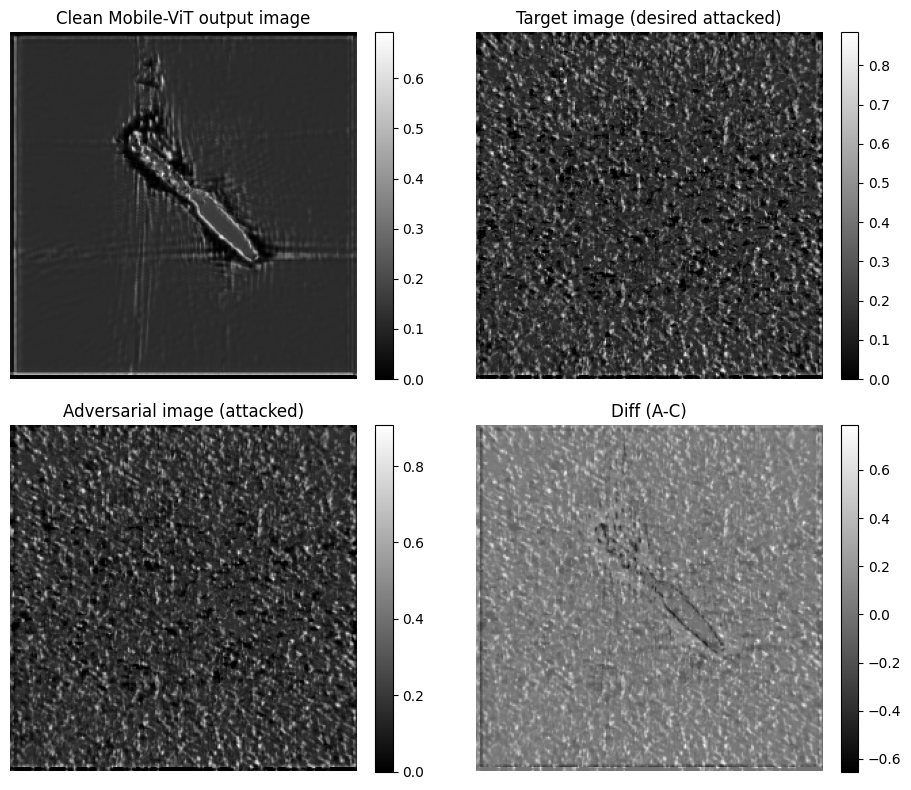

In [27]:
mse_val  = np.mean((adv_img - target_img) ** 2)
mse_val2 = np.mean((adv_img/np.sqrt(np.mean(np.square(adv_img))) - target_img/np.sqrt(np.mean(np.square(target_img)))) ** 2)

mse_CA = np.mean((adv_img - clean_img) ** 2)      # MSE(Adv, Clean)

num = np.sum((adv_img * target_img))
den = np.sqrt(np.sum(adv_img**2) * np.sum(target_img**2)) + 1e-12
ncc_val = num / den

att_gray = np.mean(adv_img, axis=2)
tgt_gray = np.mean(target_img, axis=2)
data_range = float(tgt_gray.max() - tgt_gray.min() + 1e-12)
ssim_val = ssim(att_gray, tgt_gray, data_range=data_range)
psnr_val = psnr(tgt_gray, att_gray, data_range=data_range)

print("\n--- Mobile-ViT SR-level attack metrics ---")
print(f"MSE(A,T)   : {mse_val:.4e}  (matlab equivalent: {mse_val2:.4e})")
print(f"MSE(C,A)   : {mse_CA:.4e}")

print(f"NCC   : {ncc_val:.4f}")
print(f"SSIM  : {ssim_val:.4f}")
print(f"PSNR  : {psnr_val:.2f} dB")


plt.figure(figsize=(10, 8))

ax1 = plt.subplot(2,2,1)
im1 = ax1.imshow(clean_img, cmap="gray")
ax1.set_title("Clean Mobile-ViT output image"); ax1.axis("off")
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

ax2 = plt.subplot(2,2,2)
im2 = ax2.imshow(target_img, cmap="gray")
ax2.set_title("Target image (desired attacked)"); ax2.axis("off")
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

ax3 = plt.subplot(2,2,3)
im3 = ax3.imshow(adv_img, cmap="gray")
ax3.set_title("Adversarial image (attacked)"); ax3.axis("off")
plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

ax4 = plt.subplot(2,2,4)
im4 = ax4.imshow(adv_img - clean_img, cmap="gray")
ax4.set_title("Diff (A-C)"); ax4.axis("off")
plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()
